# 04: Building Model, BLE Model, and the Particle Filter

In [11]:
import sys
sys.path.append("../src")
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import preprocessing
import imu
import building
import ble
import evaluation
import particle_filter as pf
import visualization as viz

RAW = "../data/raw"
REF = "../assignment/Paths_references.xlsx"

run = preprocessing.load_run(1, raw_dir=RAW)
cfg = preprocessing.RUN_START[1]
motion = imu.build_motion_table(run, initial_heading=cfg["initial_heading"])

## M2: The building model

Each floor is one main corridor plus a short east stub, described by a centre-line
poly-line with a half-width: a point is *walkable* if it lies within that
half-width. The world frame is metric with the origin at the west staircase
(x = east, y = north) and a separate floor index. Doors sit on the corridor
centre-line; beacons are the six marked on the paths; floor changes are allowed
only inside the two staircase zones. The scale (~5.25 m door spacing) is derived
from the counted step totals in the reference (decision D4).

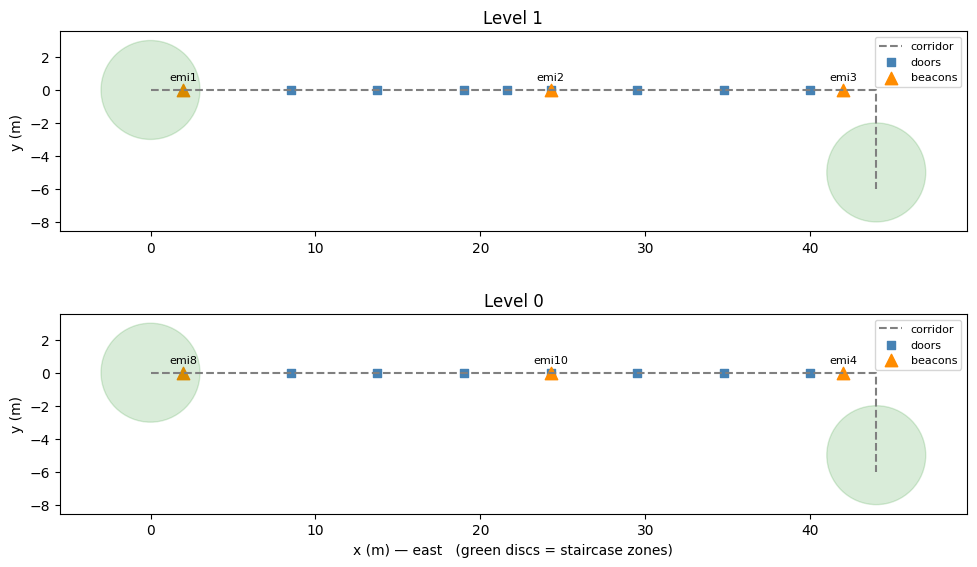

In [12]:
doors = building.door_positions()
beacons = building.beacon_positions()

fig, axes = plt.subplots(2, 1, figsize=(10, 6))
for floor_index, ax in zip([1, 0], axes):
    polyline = building.corridor_polyline(floor_index)
    ax.plot([p[0] for p in polyline], [p[1] for p in polyline],
            "--", color="gray", label="corridor")

    floor_doors = [v for k, v in doors.items() if k[0] == floor_index]
    ax.scatter([d[0] for d in floor_doors], [d[1] for d in floor_doors],
               marker="s", s=30, color="steelblue", label="doors")

    floor_beacons = {n: p for n, p in beacons.items() if p[2] == floor_index}
    ax.scatter([p[0] for p in floor_beacons.values()],
               [p[1] for p in floor_beacons.values()],
               marker="^", s=80, color="darkorange", label="beacons")
    for name, p in floor_beacons.items():
        ax.annotate(name.replace("arrive_", ""), (p[0], p[1]),
                    textcoords="offset points", xytext=(0, 7), fontsize=8, ha="center")

    for cx, cy in [building.WEST_STAIRCASE, building.EAST_STAIRCASE]:
        ax.add_patch(plt.Circle((cx, cy), building.STAIRCASE_RADIUS_M,
                                color="green", alpha=0.15))

    ax.set_title("Level %d" % floor_index)
    ax.set_ylabel("y (m)")
    ax.set_aspect("equal")
    ax.legend(loc="upper right", fontsize=8)
axes[-1].set_xlabel("x (m) — east   (green discs = staircase zones)")
plt.tight_layout()
plt.show()

Quick validity checks: a point on the corridor is walkable, a point off it is not,
and the staircase zones sit at the two ends.

In [14]:
print("is_walkable(20, 0.0, 0)  :", building.is_walkable(20, 0.0, 0))   # on the corridor
print("is_walkable(20, 3.0, 0)  :", building.is_walkable(20, 3.0, 0))   # through a wall
print("can_change_floor(0, 0)   :", building.can_change_floor(0, 0))    # west staircase
print("can_change_floor(20, 0)  :", building.can_change_floor(20, 0))   # mid-corridor

is_walkable(20, 0.0, 0)  : True
is_walkable(20, 3.0, 0)  : False
can_change_floor(0, 0)   : True
can_change_floor(20, 0)  : False


## M4: The BLE observation model

A beacon close to the phone is heard strongly; a distant one weakly. The
log-distance path-loss model captures this, and for one reading we weight each
particle by how well its position explains the observed RSSI (a Gaussian on the
RSSI residual). The parameters were **calibrated to the reference distances**
(decision D14): the real corridor path loss is much flatter than free space.

calibrated path-loss: RSSI_AT_1M=-59.0, exponent=2.50, sigma=4.0


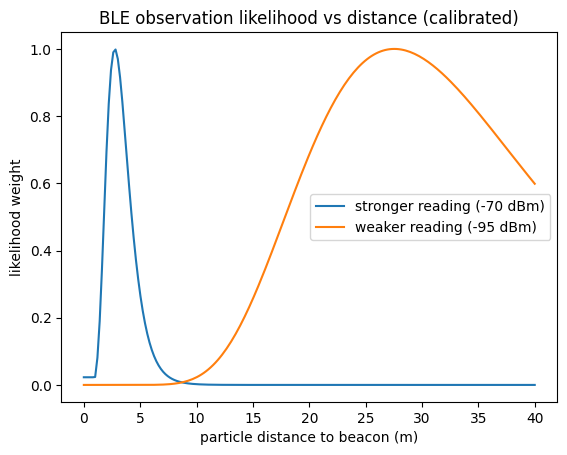

In [15]:
print("calibrated path-loss: RSSI_AT_1M=%.1f, exponent=%.2f, sigma=%.1f"
      % (ble.RSSI_AT_1M, ble.PATH_LOSS_EXPONENT, ble.RSSI_SIGMA))

# Weight of a particle vs its distance to one beacon, for a stronger and weaker read.
distance = np.linspace(0, 40, 200)
beacon_position = (0.0, 0.0, 0)
zeros = np.zeros_like(distance)
for observed_rssi, label in [(-70.0, "stronger reading (-70 dBm)"),
                             (-95.0, "weaker reading (-95 dBm)")]:
    weights = ble.rssi_likelihood(distance, zeros, zeros.astype(int),
                                  beacon_position, observed_rssi)
    plt.plot(distance, weights, label=label)
plt.xlabel("particle distance to beacon (m)")
plt.ylabel("likelihood weight")
plt.title("BLE observation likelihood vs distance (calibrated)")
plt.legend()
plt.show()

## M5: The particle filter, built in sub-steps


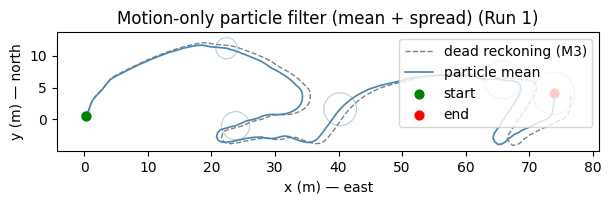

In [16]:
# Deterministic dead-reckoning reference (motion only, no noise).
dx = motion["step_length"] * np.cos(motion["heading"])
dy = motion["step_length"] * np.sin(motion["heading"])
dead_reckoning = pd.DataFrame({"x": np.r_[cfg["start"][0], cfg["start"][0] + dx.cumsum()],
                               "y": np.r_[cfg["start"][1], cfg["start"][1] + dy.cumsum()]})

traj_5a, spread_5a = pf.run_motion_only(run, motion, start=cfg["start"], seed=0)
viz.plot_particle_cloud(traj_5a, spread_5a, dead_reckoning=dead_reckoning, run_id=1)
plt.show()

resamples: 85


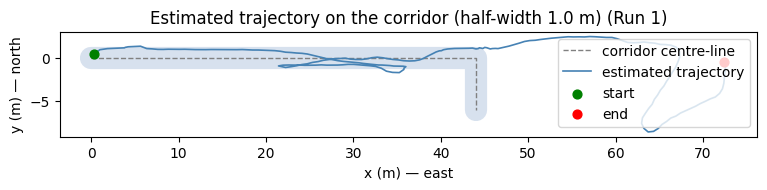

In [17]:
traj_5b, spread_5b, n_resamples_5b = pf.run_with_constraints(
    run, motion, start=cfg["start"], building=building, floor=0, seed=0)
print("resamples:", n_resamples_5b)

viz.plot_trajectory_on_corridor(traj_5b, building.corridor_polyline(0),
                                building.CORRIDOR_HALF_WIDTH_M, run_id=1)
plt.show()

### 5c — Add the BLE correction

Each BLE reading multiplies in the observation likelihood, giving the absolute
reference the map lacked. With the calibrated model, BLE agrees with the map instead
of pulling the estimate off. Beacons are marked as triangles.

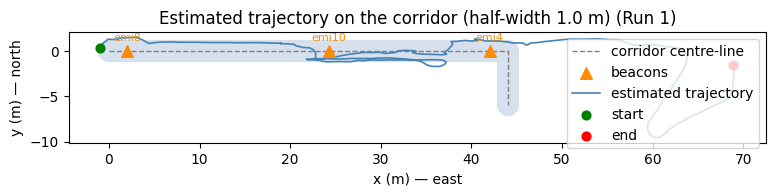

In [18]:
traj_5c, spread_5c, n_resamples_5c = pf.run_with_ble(
    run, motion, start=cfg["start"], building=building, ble=ble, floor=0, seed=0)

floor0_beacons = {n: p for n, p in building.beacon_positions().items() if p[2] == 0}
viz.plot_trajectory_on_corridor(traj_5c, building.corridor_polyline(0),
                                building.CORRIDOR_HALF_WIDTH_M,
                                beacons=floor0_beacons, run_id=1)
plt.show()

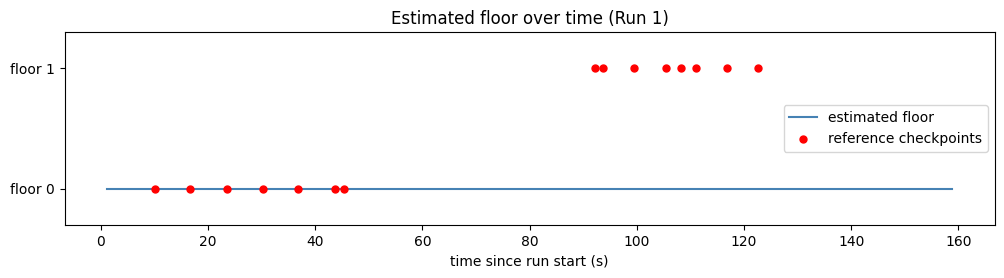

In [19]:
reference = evaluation.load_reference(1, reference_file=REF)
traj_5d, spread_5d, n_resamples_5d = pf.run_filter(
    run, motion, start=cfg["start"], floor=cfg["floor"],
    building=building, ble=ble, seed=0)

viz.plot_floor_over_time(traj_5d, reference, run_id=1)
plt.show()

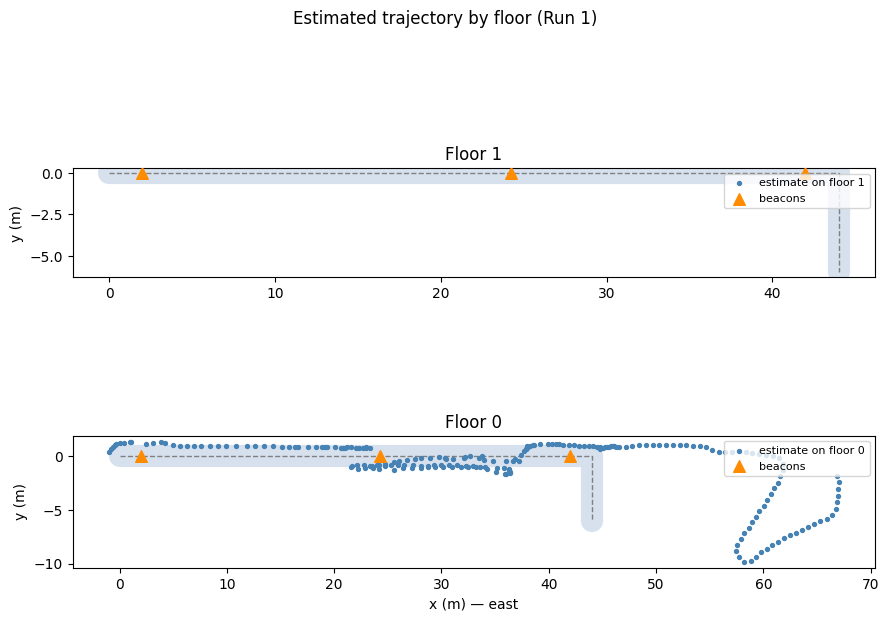

In [20]:
viz.plot_trajectory_two_floors(traj_5d, building.corridor_polyline(0),
                               building.CORRIDOR_HALF_WIDTH_M,
                               beacons=building.beacon_positions(), run_id=1)
plt.show()